In [39]:
import pandas as pd  #data manipulation
import numpy as np    # numerical operations

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)   #see all columns
sns.set_style("whitegrid")

df = pd.read_csv("../data/eda/eda2.csv")

In [40]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

y = y.map({
    "Yes": 1,
    "No": 0
})

# 1.TotalServices Feature

here i plan to create feature by combining sum of total features one customer uses. so i feel we can get good insight from it and it will help our model to train much easier

In [41]:
services = [
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["TotalServices"] = (
    (df[services] != "No").sum(axis=1)
)

In [42]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalServices
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,3
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,4
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,4
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,5
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,2


In [43]:
for i in range(0, len(services) - 1):
    result = df.loc[df['TotalServices'] > i, 'Churn'].value_counts(normalize=True)
    print(result)
    

Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64
Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64
Churn
No     0.751718
Yes    0.248282
Name: proportion, dtype: float64
Churn
No     0.784232
Yes    0.215768
Name: proportion, dtype: float64
Churn
No     0.816583
Yes    0.183417
Name: proportion, dtype: float64
Churn
No     0.849921
Yes    0.150079
Name: proportion, dtype: float64
Churn
No     0.884897
Yes    0.115103
Name: proportion, dtype: float64
Churn
No     0.927686
Yes    0.072314
Name: proportion, dtype: float64


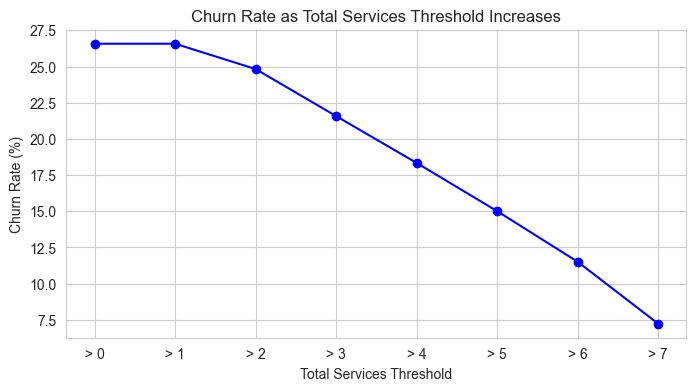

In [44]:
thresholds = []
churn_rates = []

# 2. Run the loop to collect data points
# Assumes 'Yes' represents customers who left
for i in range(0, len(services) - 1):
    # Filter and get percentages
    result = df.loc[df['TotalServices'] > i, 'Churn'].value_counts(normalize=True)
    
    # Check if 'Yes' exists in the results to avoid KeyError
    if 'Yes' in result.index:
        thresholds.append(f"> {i}")
        churn_rates.append(result['Yes'] * 100) # Convert to percentage

# 3. Plot the final aggregated trend line outside the loop
plt.figure(figsize=(8, 4))
plt.plot(thresholds, churn_rates, marker='o', linestyle='-', color='b')
plt.title('Churn Rate as Total Services Threshold Increases')
plt.xlabel('Total Services Threshold')
plt.ylabel('Churn Rate (%)')
plt.grid(True)
plt.show()

**So here what we can see is when customer use more services there is probability of churning is very low. (it keeps decreasing)**

**So we can create this feature definitely**

# 2. Is New Customer

this will be also helpful, because we saw that tenure how impacted in EDA process.

In [45]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,TotalServices
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,5.540813
std,0.368844,24.545260,30.085974,2266.771362,1.893415
min,0.000000,1.000000,18.250000,18.800000,2.000000
25%,0.000000,9.000000,35.587500,401.450000,4.000000
50%,0.000000,29.000000,70.350000,1397.475000,6.000000
75%,0.000000,55.000000,89.862500,3794.737500,7.000000
max,1.000000,72.000000,118.750000,8684.800000,9.000000


In [46]:
for i in range(0, 73, 8):
    result = (df["tenure"] < i).value_counts(normalize=True)
    print(result)

tenure
False    1.0
Name: proportion, dtype: float64
tenure
False    0.772327
True     0.227673
Name: proportion, dtype: float64
tenure
False    0.650313
True     0.349687
Name: proportion, dtype: float64
tenure
False    0.558447
True     0.441553
Name: proportion, dtype: float64
tenure
True     0.525455
False    0.474545
Name: proportion, dtype: float64
tenure
True     0.598834
False    0.401166
Name: proportion, dtype: float64
tenure
True     0.672497
False    0.327503
Name: proportion, dtype: float64
tenure
True     0.750427
False    0.249573
Name: proportion, dtype: float64
tenure
True     0.830916
False    0.169084
Name: proportion, dtype: float64
tenure
True     0.948521
False    0.051479
Name: proportion, dtype: float64


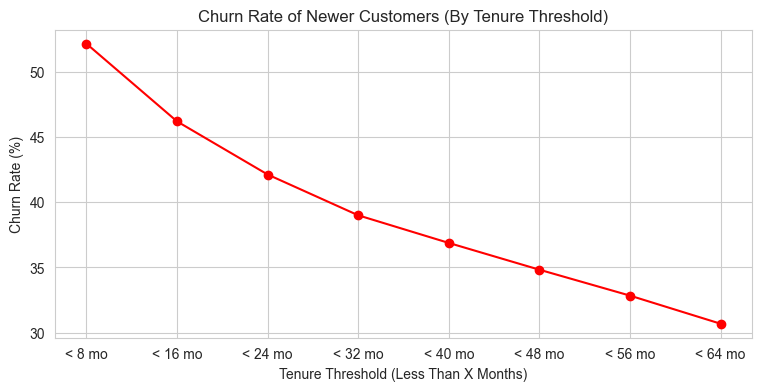

In [47]:

thresholds = []
new_rates = []

# Loop through tenure month thresholds (0 to 72 months, steps of 8)
for i in range(0, 72, 8):
    # 1. Filter the dataframe for customers with tenure LESS than i months
    subset = df[df["tenure"] < i]
    
    # Handle the first loop (i=0) or empty slices to prevent DivisionByZero errors
    if len(subset) == 0:
        continue
        
    # 2. Get the normalized churn distribution within this specific subset
    result = subset['Churn'].value_counts(normalize=True)
    
    # 3. Safely check if 'Yes' (churned) exists in the subset index
    if 'Yes' in result.index:
        thresholds.append(f"< {i} mo")       # Corrected label to reflect "Less than"
        new_rates.append(result['Yes'] * 100) # Percentage of churn within this tenure bracket

# 4. Plot the final aggregated trend line
plt.figure(figsize=(9, 4))
plt.plot(thresholds, new_rates, marker='o', linestyle='-', color='r') # Changed color to 'r' for contrast

plt.title('Churn Rate of Newer Customers (By Tenure Threshold)')
plt.xlabel('Tenure Threshold (Less Than X Months)')
plt.ylabel('Churn Rate (%)')
plt.grid(True)
plt.show()


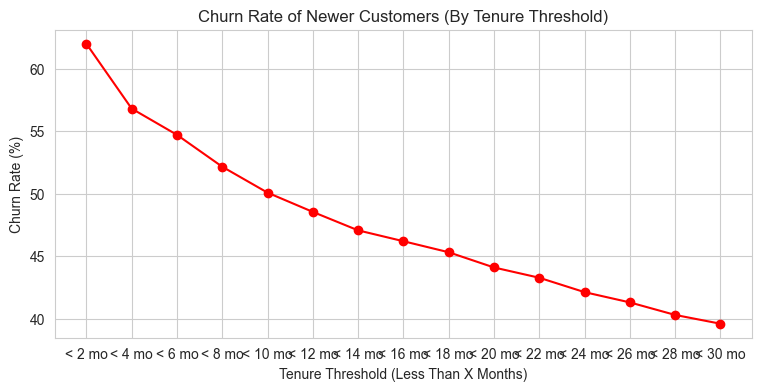

In [48]:

thresholds = []
new_rates = []

# Loop through tenure month thresholds (0 to 72 months, steps of 8)
for i in range(0, 32, 2):
    # 1. Filter the dataframe for customers with tenure LESS than i months
    subset = df[df["tenure"] < i]
    
    # Handle the first loop (i=0) or empty slices to prevent DivisionByZero errors
    if len(subset) == 0:
        continue
        
    # 2. Get the normalized churn distribution within this specific subset
    result = subset['Churn'].value_counts(normalize=True)
    
    # 3. Safely check if 'Yes' (churned) exists in the subset index
    if 'Yes' in result.index:
        thresholds.append(f"< {i} mo")       # Corrected label to reflect "Less than"
        new_rates.append(result['Yes'] * 100) # Percentage of churn within this tenure bracket

# 4. Plot the final aggregated trend line
plt.figure(figsize=(9, 4))
plt.plot(thresholds, new_rates, marker='o', linestyle='-', color='r') # Changed color to 'r' for contrast

plt.title('Churn Rate of Newer Customers (By Tenure Threshold)')
plt.xlabel('Tenure Threshold (Less Than X Months)')
plt.ylabel('Churn Rate (%)')
plt.grid(True)
plt.show()


from here it feels like 14 months is good threshold. but in reality we can get if less than year then new customer. so lets get 12 as threshold.


In [49]:
## create Is new Customer feature
df["IsNewCustomer"] = (
    df["tenure"] < 12
).astype(int)

In [50]:
df.shape

(7032, 22)

In [51]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalServices,IsNewCustomer
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,3,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,4,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,4,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,5,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,2,1


# 3. Contract Risk Category

we saw that `month-to-month` category had highest potential churn rate. we know that most short term customers are likely to churn because they come to test whether service is good or bad. so if they not satisfy they leave. so we can seperate it.

In [52]:
df["HighRiskContract"] = (
    df["Contract"] == "Month-to-month"
).astype(int)

# 4. Has security bundle category

**we noticed that when user has internet service they expected security, tech support and device protection. so simply they expected security bundle. so lets create feautre based on that**

In [53]:
df["HasProtection"] = (
    (
        (df["OnlineSecurity"] == "Yes") |
        (df["TechSupport"] == "Yes") |
        (df["DeviceProtection"] == "Yes")
    ).astype(int)
)